In [1]:
import datasets
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import numpy as np
# use retina mode
%config InlineBackend.figure_format = 'retina'

from nanomoe.data import PackedPretrainDataset, unpack_batch
from nanomoe.model import MoEConfig, create_model
from nanomoe.model.attention import Attention
from nanomoe.monitors import (
    HiddenStateMonitorResult,
    NeighbourLayerHiddenStateStats,
    TokenHiddenStateLayerStats,
    hidden_state_cosine_similarities
)
from nanomoe.data.packed_dataset import PackedPretrainStreamGroup, cu_seqlens_to_packing_metadata

/weka/scratch/enalisn1/xwang/nanomoe/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/weka/scratch/enalisn1/xwang/nanomoe/.venv/lib/python3.13/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
@torch.no_grad()
def get_model_metrics(model, dataset):
    results = hidden_state_cosine_similarities(
        model=model,
        dataset=dataset,
        batch_size=1,
        max_batches=1,
        first_layer_as_reference=True,
    )

    all_avg_cos = [
        r.mean_off_diagonal_cosine
        for r in results.intra_sequence
    ]
    all_neighbour_layer_stats = [
        (r.mean_token_cosine, r.mean_rms_distance, r.mean_relative_rms_change)
        for r in results.neighbouring_layers
    ]
    all_first_layer_stats = [
        (r.mean_token_cosine, r.mean_rms_distance, r.mean_relative_rms_change)
        for r in results.first_layer_reference
    ]
    all_router_stats = [
        r.entropy for r in results.router_usage_entropy
    ]
    return {
        "all_avg_cos": all_avg_cos,
        "all_neighbour_layer_stats": all_neighbour_layer_stats,
        "all_first_layer_stats": all_first_layer_stats,
        "all_router_stats": all_router_stats,
    }

In [4]:
tokenizer_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
num_layer = 32

# seq_len = 16374
# 4096
seq_len = 2048
max_seq_len = 2048

dataset_name = "Salesforce/wikitext"
dataset_config = "wikitext-2-raw-v1"
# dataset_name = "nvidia/Nemotron-CC-Math-v1"
# dataset_config = "4plus"
dataset_split = "train"
text_key = "text"
hf_dataset = datasets.load_dataset(dataset_name, dataset_config, split=dataset_split, streaming=True)

dataset = PackedPretrainStreamGroup(
    hf_dataset=hf_dataset,
    tokenizer=tokenizer,
    num_streams=1,
    total_shards=1,
    shard_base_index=0,
    seq_len=seq_len,
    max_seq_len=max_seq_len,
    text_key="text",
    min_doc_len=64,
    prefetch_batches=1,
    seed=0,
    add_special_tokens=False,
 )

In [13]:
num_experts = 128
NUM_EXPERTS = num_experts
num_experts_per_tok = 2
seed = 2

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(seed)
if device.type == "cuda":
    torch.cuda.manual_seed_all(seed)


constant, alpha = 0.2, 0.5
# constant, alpha = 1.0, 0.0
residual_scale = constant / (num_layer ** alpha)
config = MoEConfig(
    hidden_size=2048,
    num_layers=num_layer,
    vocab_size=len(tokenizer),
    num_attention_heads=32,
    num_key_value_heads=32,
    intermediate_size=512,
    num_experts=NUM_EXPERTS,
    num_experts_per_tok=num_experts_per_tok,
    depth_alpha=None,
    residual_scale=residual_scale,
    tie_word_embeddings=False,
 )

model = create_model(config).to(device).eval()
print(f"device={device}, tokenizer_vocab={len(tokenizer):,}, parameters={model.num_parameters() / 1e6:,}M")
model_metrics_depth_scaling = get_model_metrics(model, dataset)
del model

device=cuda, tokenizer_vocab=50,257, parameters=13,636.1472M


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
if device.type == "cuda":
    torch.cuda.manual_seed_all(0)


# constant, alpha = 0.2, 0.5
constant, alpha = 1.0, 0.0
residual_scale = constant / (num_layer ** alpha)
config = MoEConfig(
    hidden_size=2048,
    num_layers=num_layer,
    vocab_size=len(tokenizer),
    num_attention_heads=32,
    num_key_value_heads=32,
    intermediate_size=512,
    num_experts=NUM_EXPERTS,
    num_experts_per_tok=num_experts_per_tok,
    depth_alpha=None,
    residual_scale=residual_scale,
    tie_word_embeddings=False,
)

model = create_model(config).to(device).eval()
print(f"device={device}, tokenizer_vocab={len(tokenizer):,}, parameters={model.num_parameters() / 1e6:,}M")
model_metrics_no_depth_scaling = get_model_metrics(model, dataset)
del model

device=cuda, tokenizer_vocab=50,257, parameters=13,636.1472M


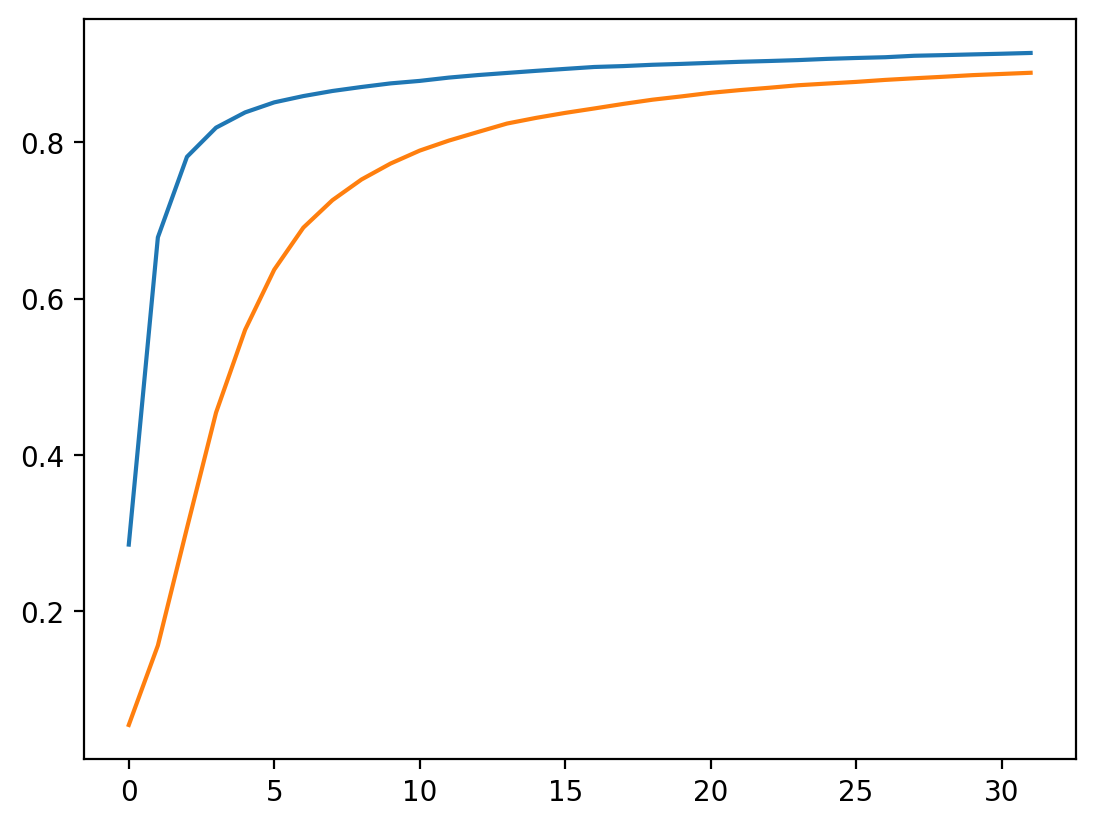

In [16]:
plt.plot(np.array(model_metrics_no_depth_scaling['all_avg_cos']))
plt.plot(np.array(model_metrics_depth_scaling['all_avg_cos']))

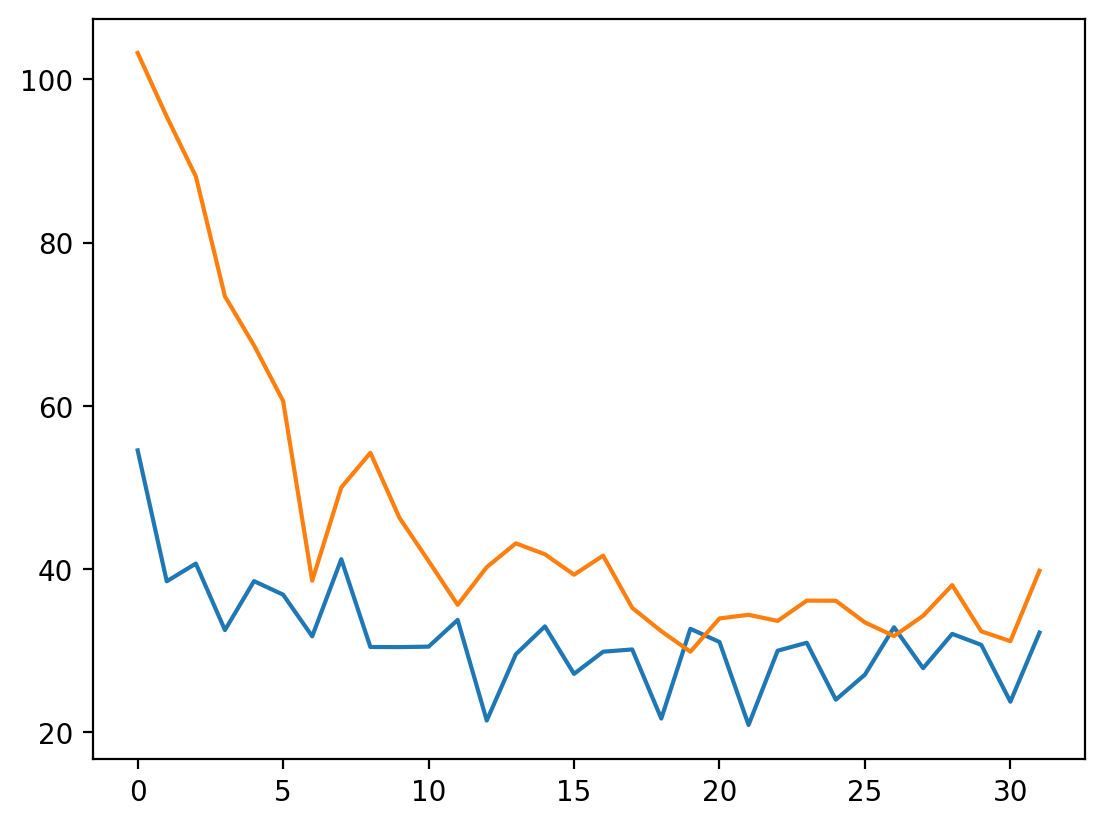

In [17]:
plt.plot(2 ** np.array(model_metrics_no_depth_scaling['all_router_stats']))
plt.plot(2 ** np.array(model_metrics_depth_scaling['all_router_stats']))

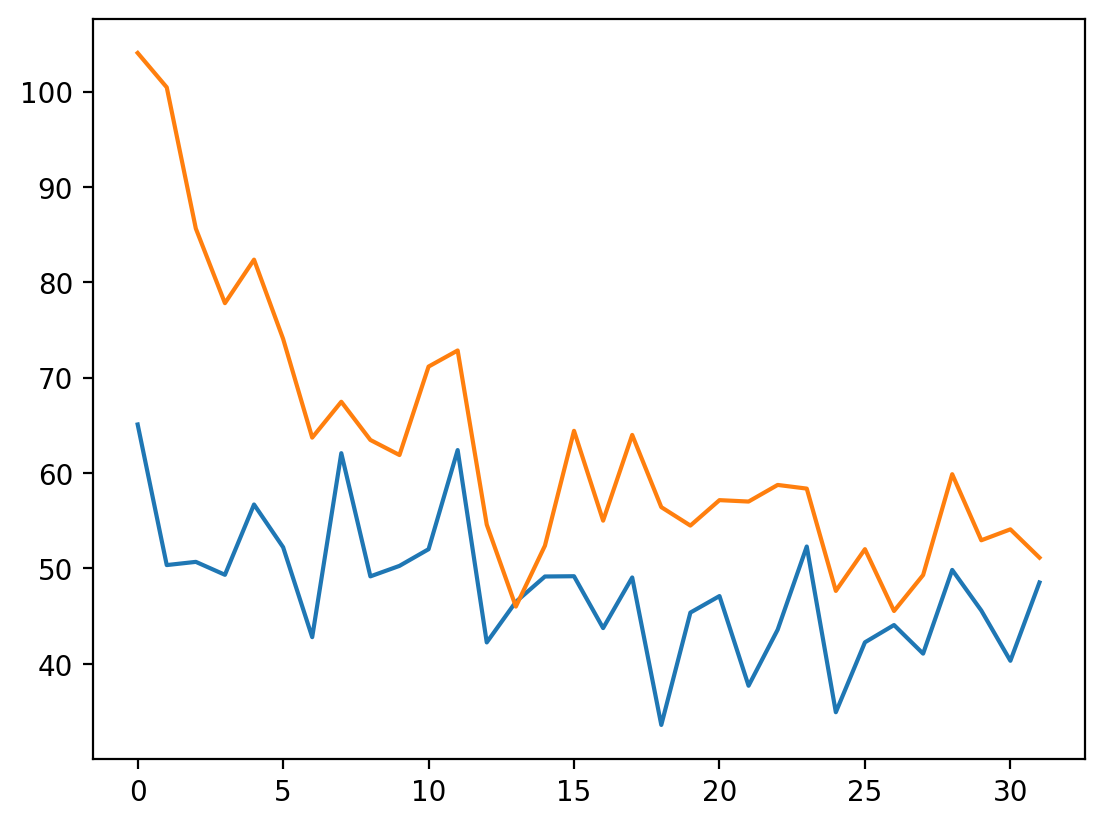

In [8]:
plt.plot(2 ** np.array(model_metrics_no_depth_scaling['all_router_stats']))
plt.plot(2 ** np.array(model_metrics_depth_scaling['all_router_stats']))

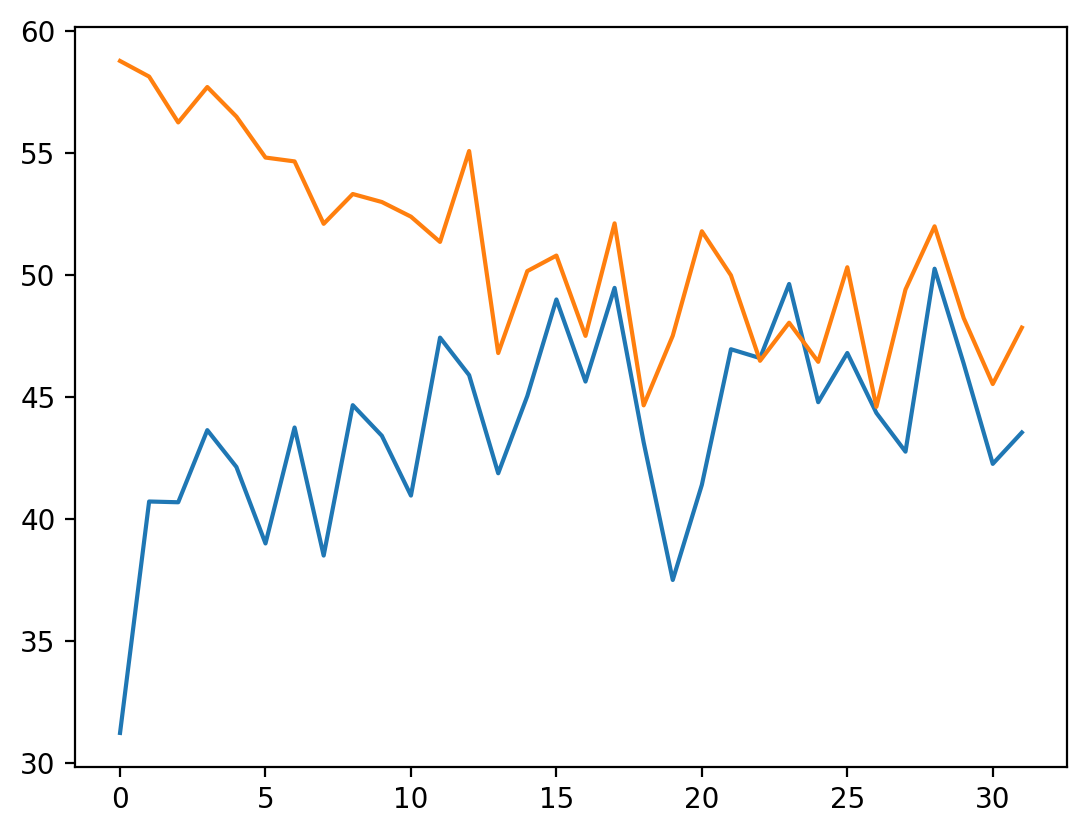

In [25]:
plt.plot(2 ** np.array(model_metrics_no_depth_scaling['all_router_stats']))
plt.plot(2 ** np.array(model_metrics_depth_scaling['all_router_stats']))

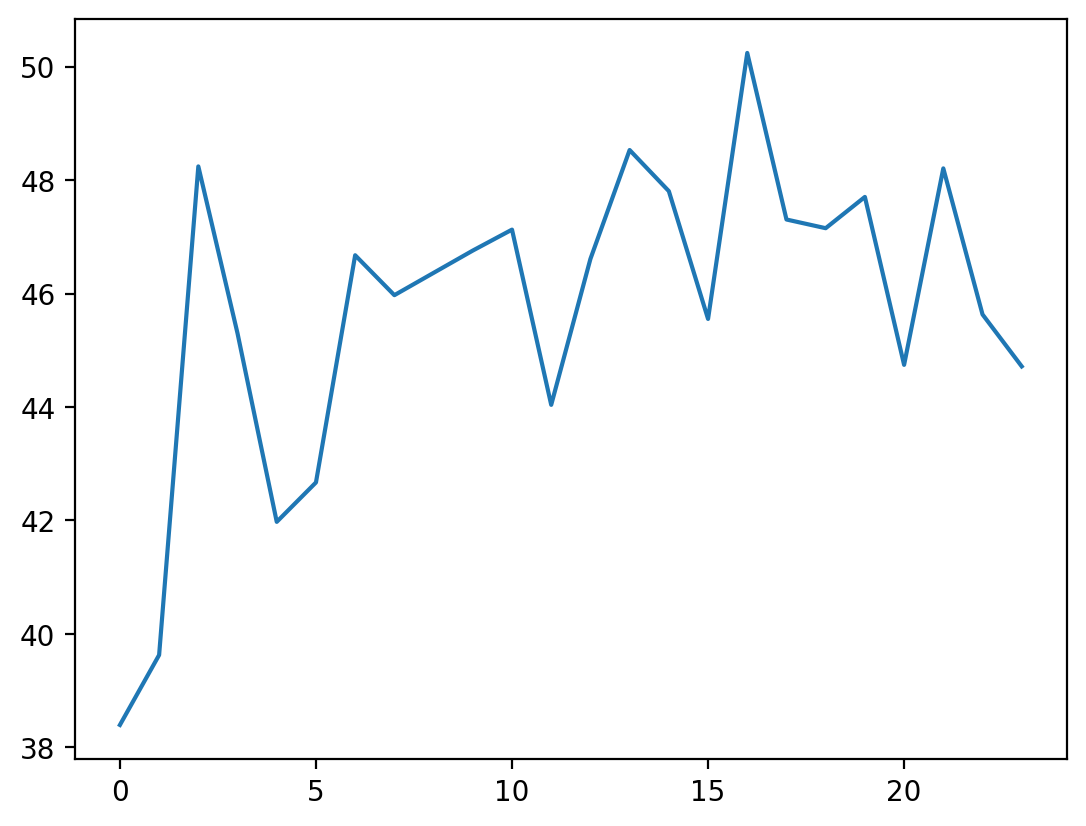

In [15]:
plt.plot(2 ** np.array(all_router_stats))

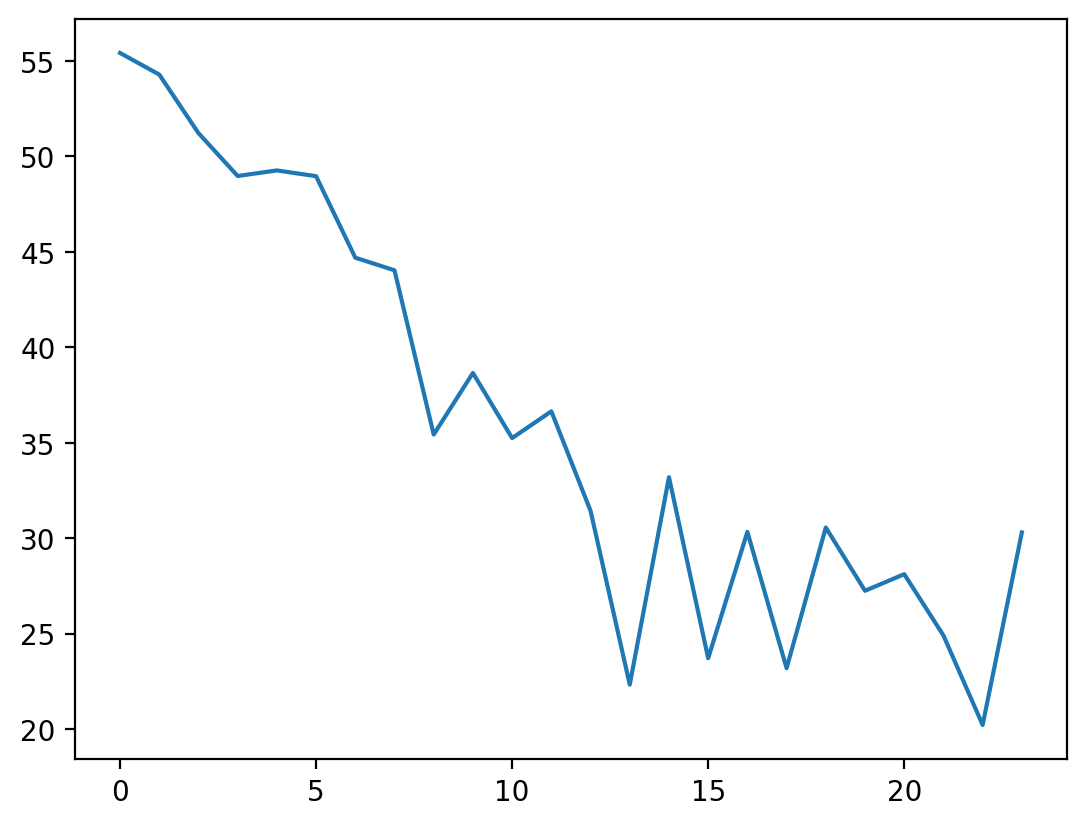

In [6]:
plt.plot(2 ** np.array(all_router_stats))

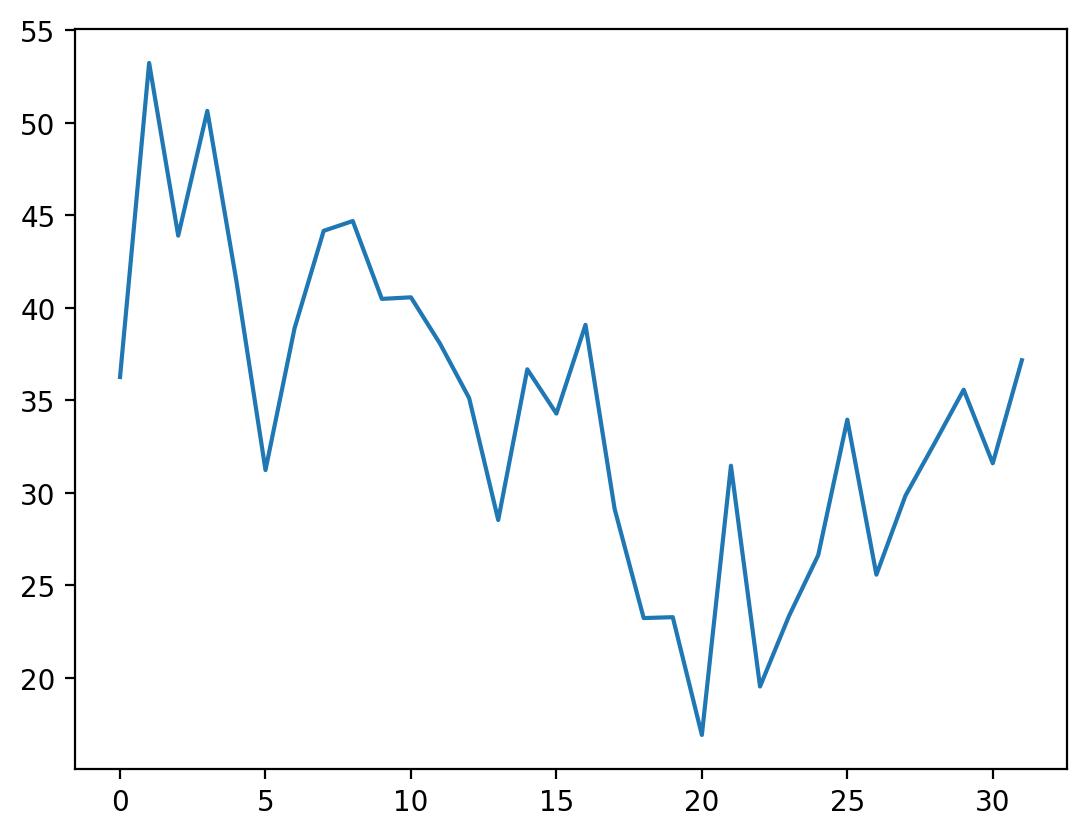

In [30]:
plt.plot(2 ** np.array(all_router_stats))

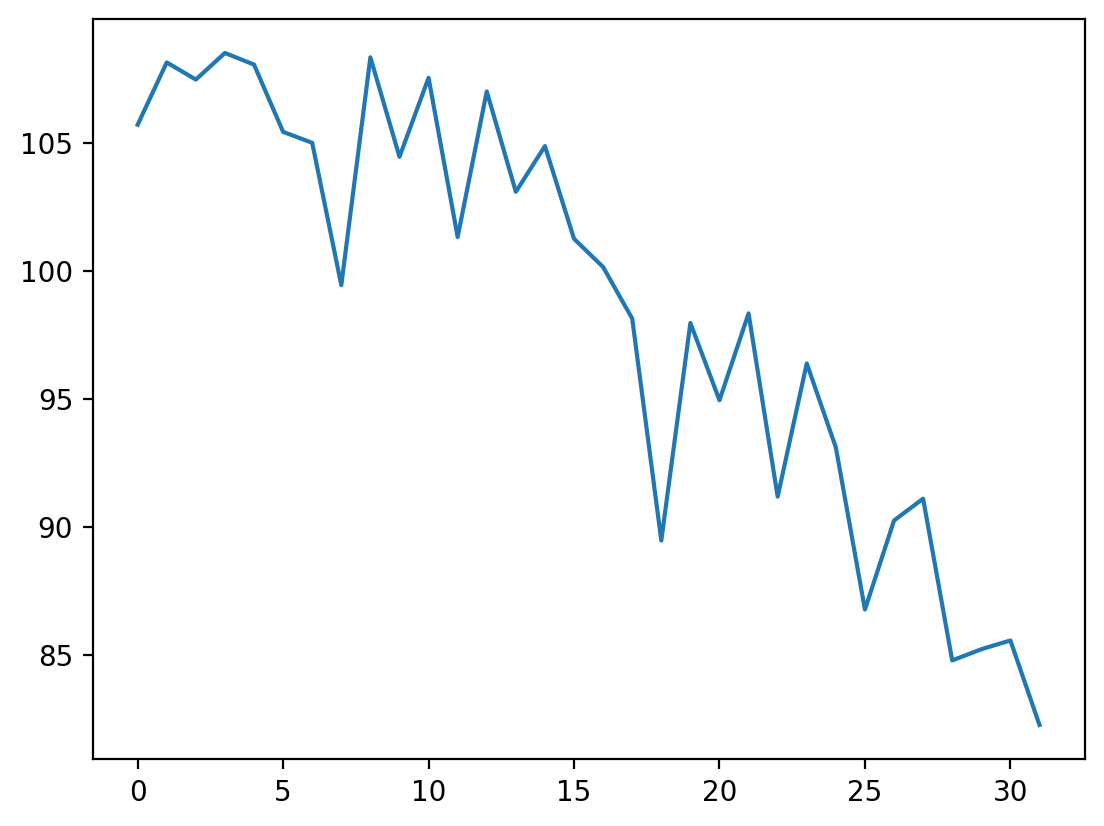

In [20]:
plt.plot(2 ** np.array(all_router_stats))

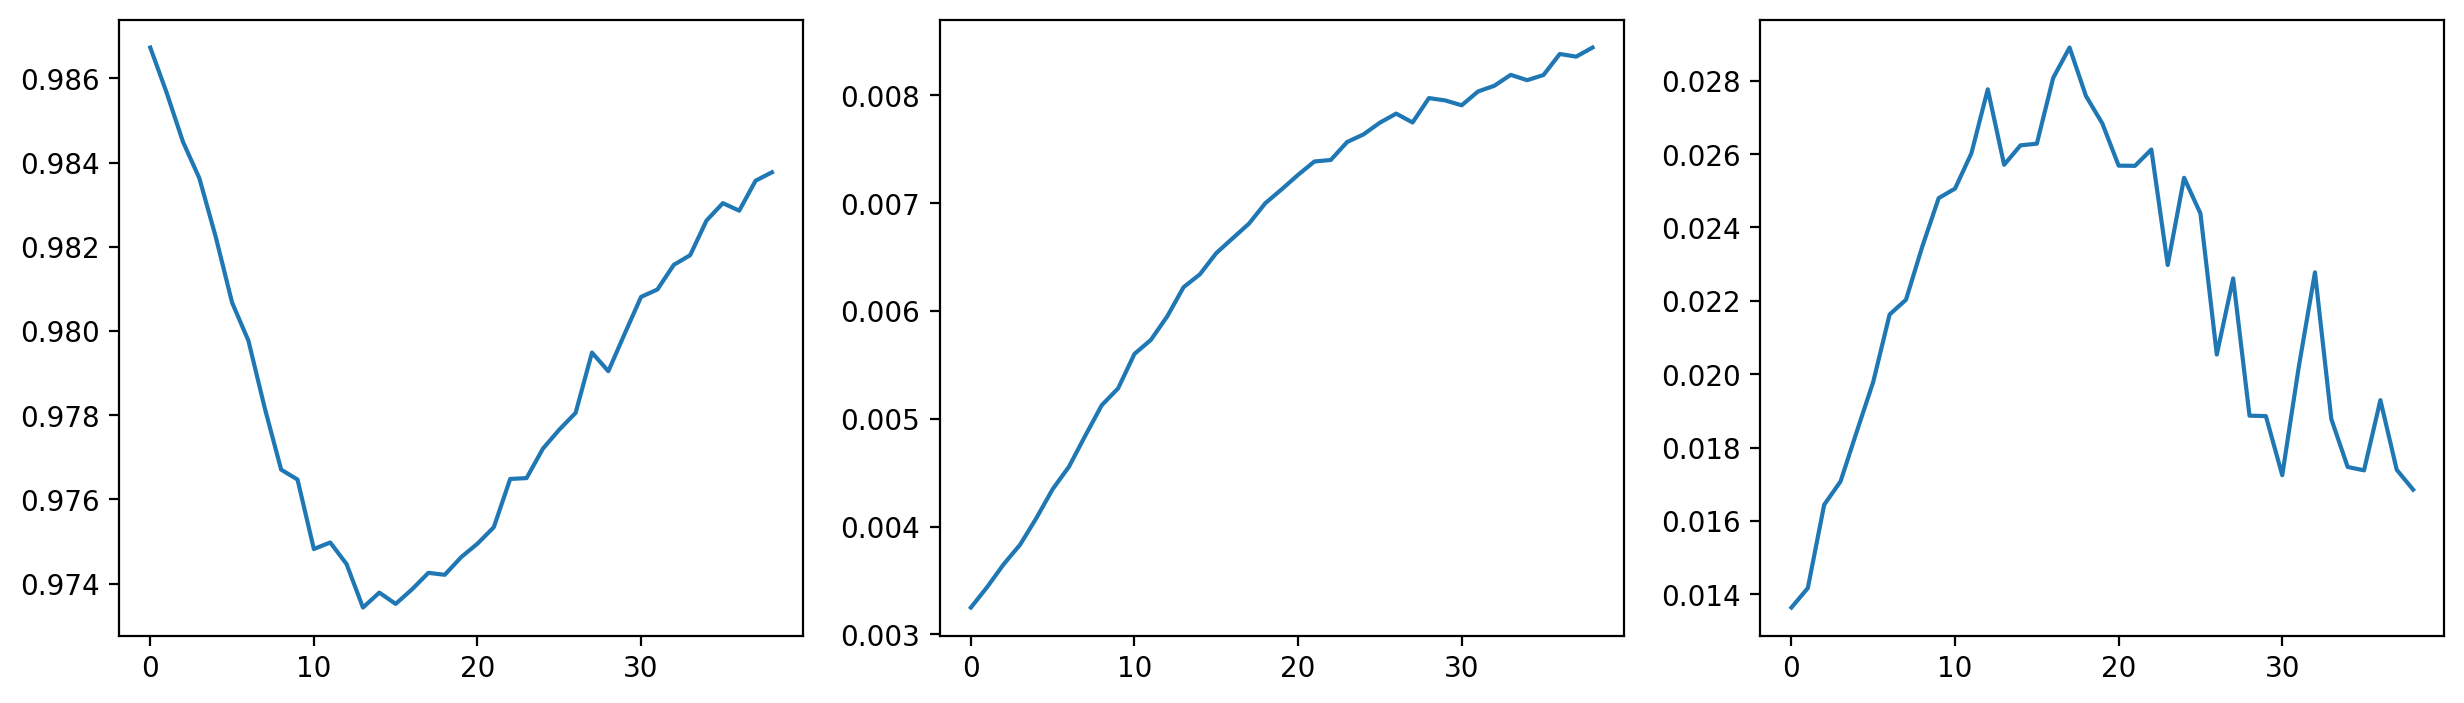

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i in range(3):
    axes[i].plot(np.array(all_neighbour_layer_stats)[:, i])
# plt.plot(np.array(all_neighbour_layer_stats)[:, 2])
# plt.plot(np.array(all_avg_cos))
# plt.ylim(0, 1)

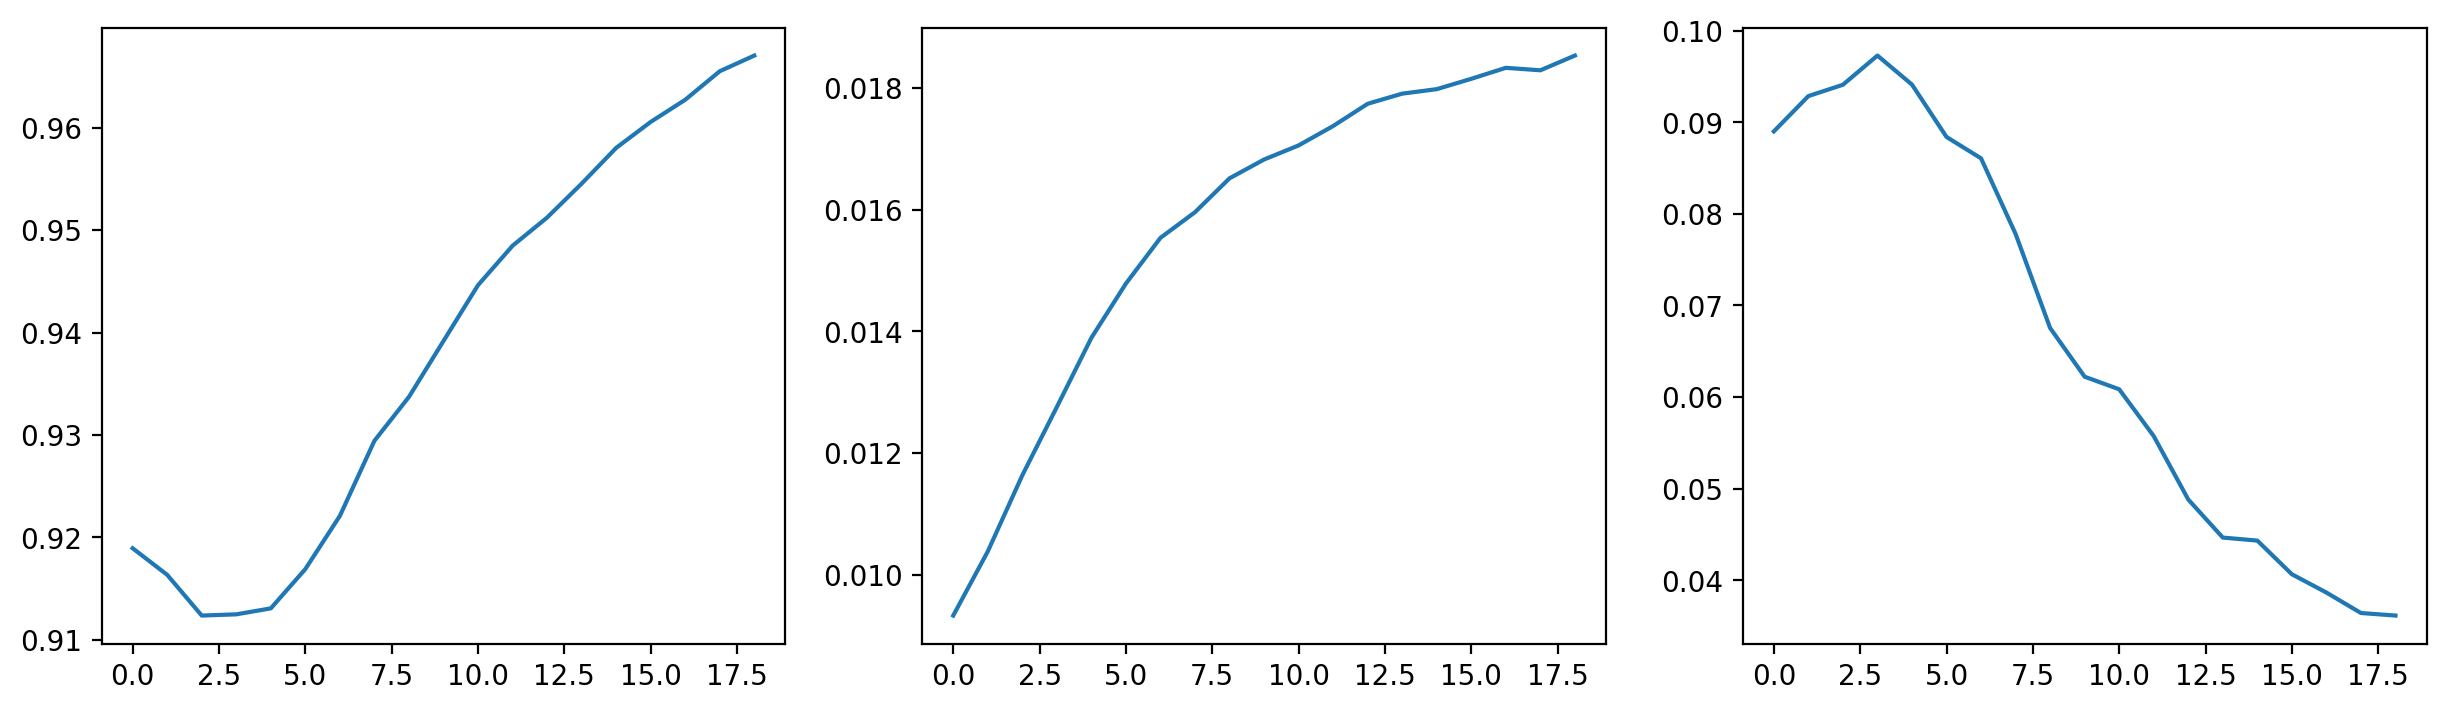

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i in range(3):
    axes[i].plot(np.array(all_neighbour_layer_stats)[:, i])
# plt.plot(np.array(all_neighbour_layer_stats)[:, 2])
# plt.plot(np.array(all_avg_cos))
# plt.ylim(0, 1)

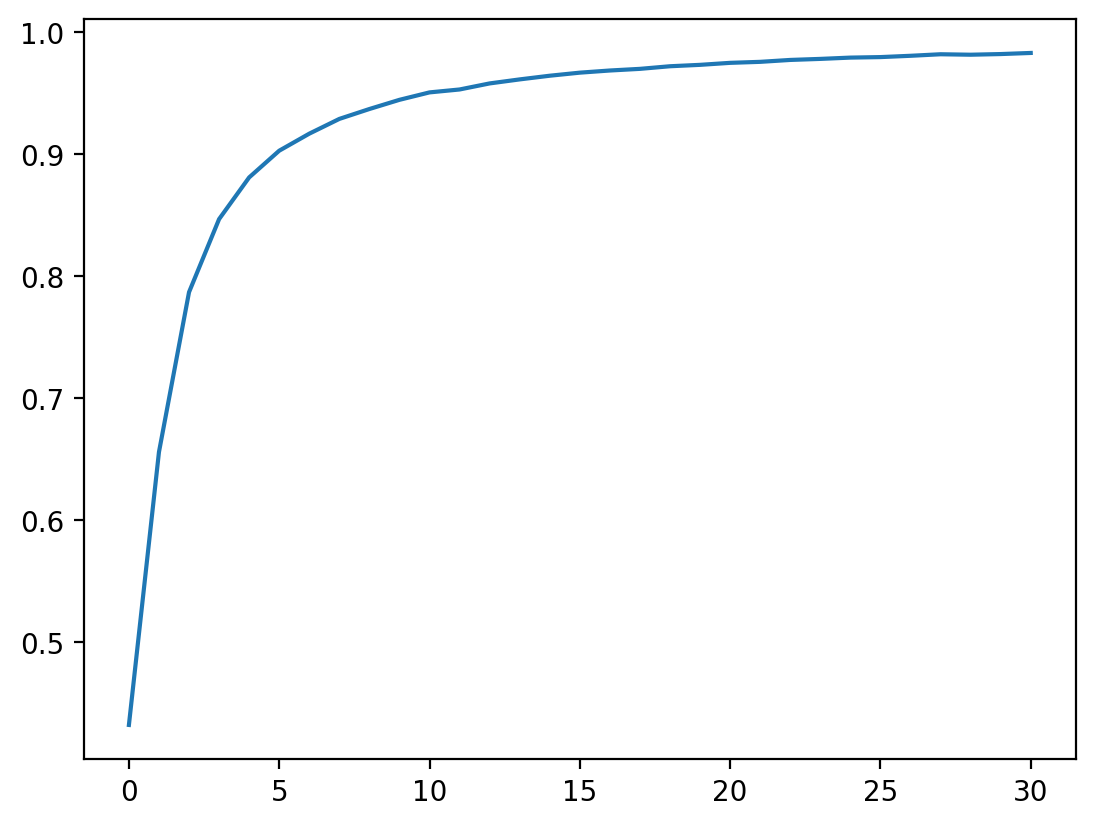

In [49]:
plt.plot(np.array(all_neighbour_layer_stats))
# plt.plot(np.array(all_avg_cos))
# plt.ylim(0, 1)

(0.0, 1.0)

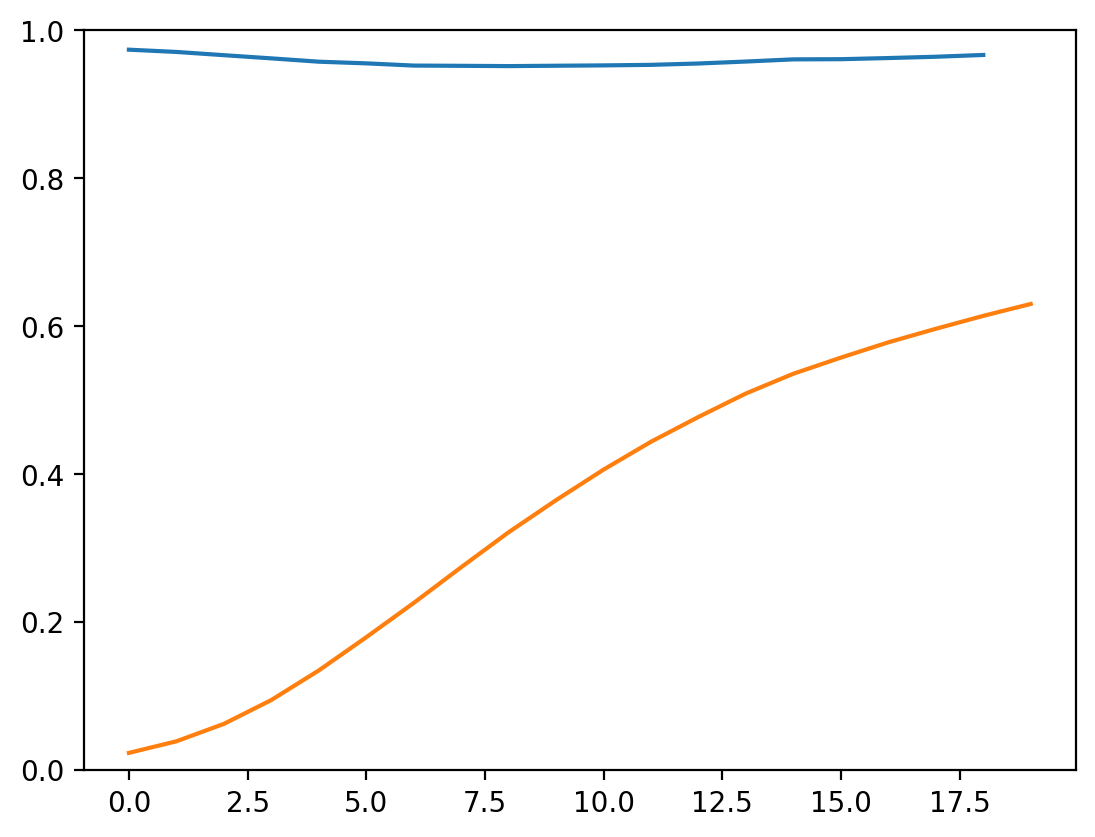

In [28]:
plt.plot(np.array(all_neighbour_layer_stats))
plt.plot(np.array(all_avg_cos))
plt.ylim(0, 1)

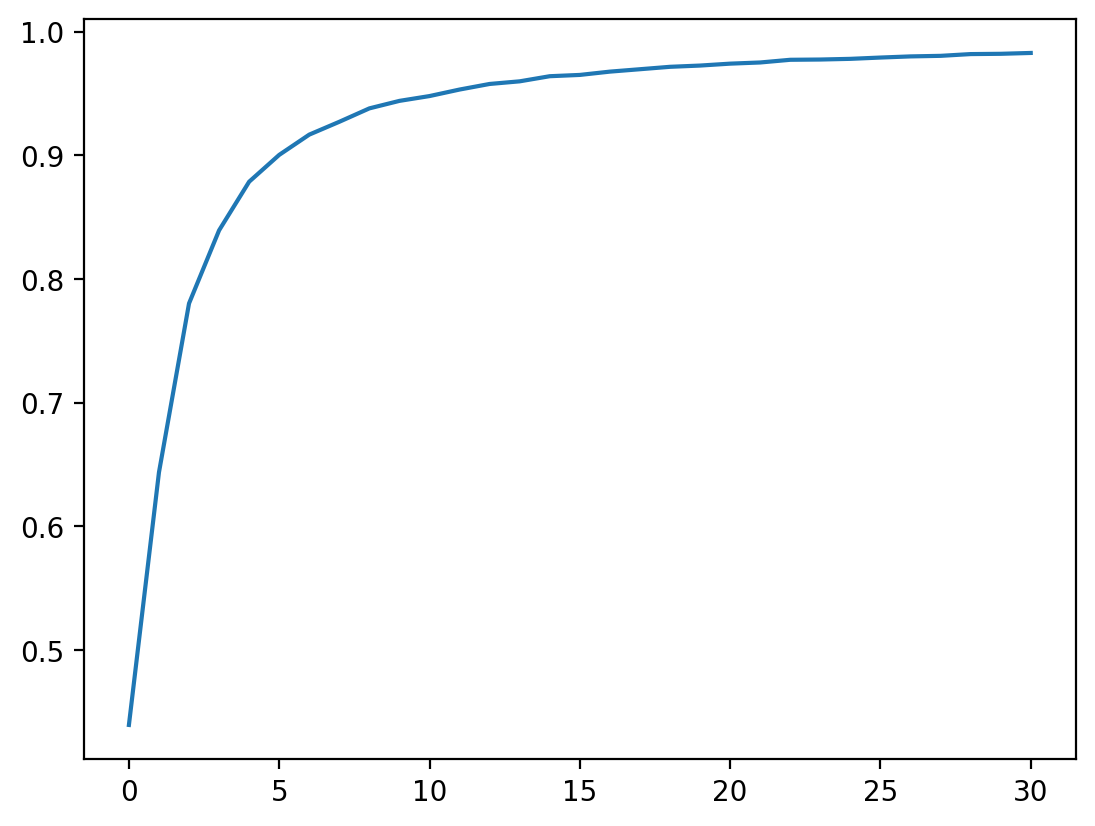

In [8]:
plt.plot(np.array(all_neighbour_layer_stats))

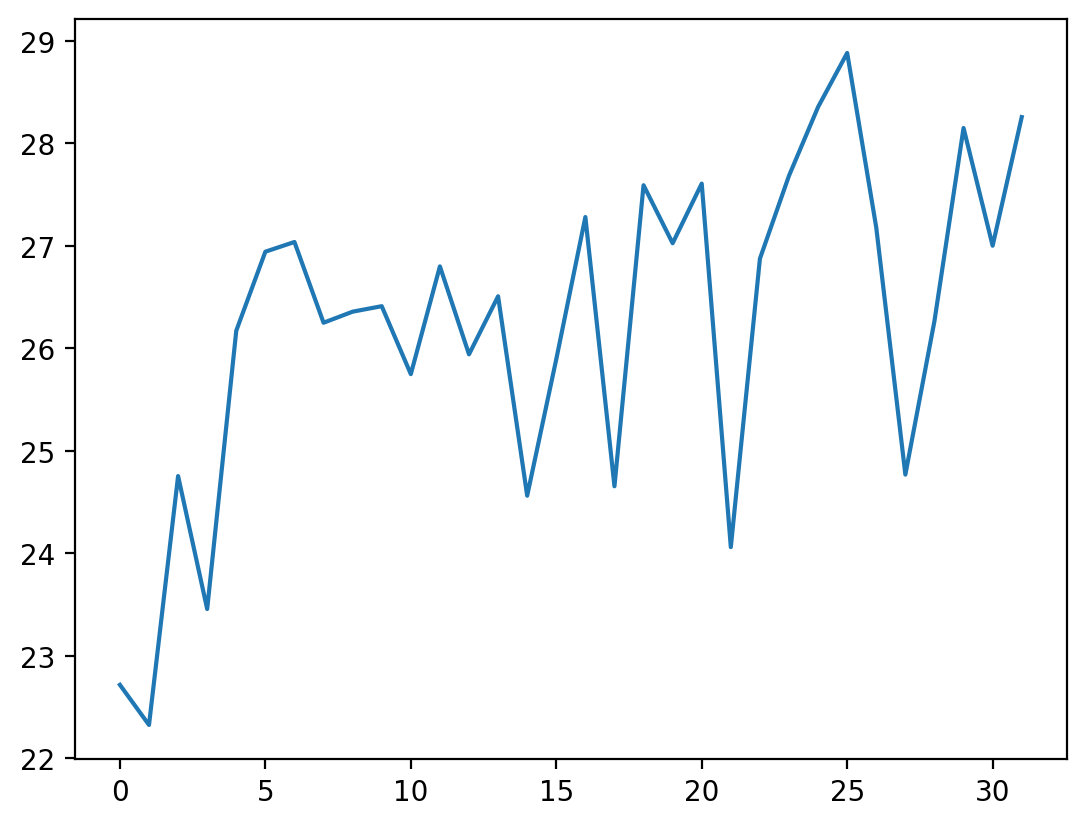

In [6]:
plt.plot(2 ** np.array(all_router_stats))